In [20]:
%pip install -Uq pandas adjdatatools scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv("./aux/stroke/healthcare-dataset-stroke-data.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Бинарная классификация вероятности инсульта

Датасет содержит данные о здоровье людей и факт перенесённого инсульта (последняя колонка 0 — нет, 1 — да)

### 0. Предобработка

Так как в датасете уже есть классы, требуется только преобразовать данные в числовой вид и нормализовать их

In [4]:
# ID пациента не даёт данных для классификации
df = df.drop(columns=["id"])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [8]:
# Дропаем NaN в колонке BMI
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   object 
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   object 
 5   work_type          4909 non-null   object 
 6   Residence_type     4909 non-null   object 
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   object 
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 460.2+ KB


In [9]:
for column in df.columns:
    print("\n" + column + "\n\t")
    print(df[column].unique())
    print("-"*40)


gender
	
['Male' 'Female' 'Other']
----------------------------------------

age
	
[6.70e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01 7.80e+01
 6.10e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 7.10e+01 5.20e+01
 8.20e+01 6.50e+01 5.70e+01 4.20e+01 4.80e+01 7.20e+01 5.80e+01 7.60e+01
 3.90e+01 7.70e+01 6.30e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01 5.90e+01
 6.60e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01 4.60e+01
 3.20e+01 5.10e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01 3.50e+01
 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01 4.00e+00
 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01 3.30e+01
 2.40e+01 3.60e+01 6.40e-01 3.40e+01 4.10e+01 8.80e-01 5.00e+00 2.60e+01
 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01 2.80e+01
 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00 1.00e+00
 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00 1.24e+00
 8.00e-01 4.00e-01 8.00e-02 1.48e+00 5.6

In [10]:
def integerize(column):
    replacements = {}
    i = 0
    for attribute in column.unique():
        replacements.update({attribute: i})
        i += 1
    print(replacements)
    return column.map(replacements)

In [13]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [14]:
to_replace = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for column in to_replace:
    df[column] = integerize(df[column])

df.head(15)

{'Male': 0, 'Female': 1, 'Other': 2}
{'Yes': 0, 'No': 1}
{'Private': 0, 'Self-employed': 1, 'Govt_job': 2, 'children': 3, 'Never_worked': 4}
{'Urban': 0, 'Rural': 1}
{'formerly smoked': 0, 'never smoked': 1, 'smokes': 2, 'Unknown': 3}


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
2,0,80.0,0,1,0,0,1,105.92,32.5,1,1
3,1,49.0,0,0,0,0,0,171.23,34.4,2,1
4,1,79.0,1,0,0,1,1,174.12,24.0,1,1
5,0,81.0,0,0,0,0,0,186.21,29.0,0,1
6,0,74.0,1,1,0,0,1,70.09,27.4,1,1
7,1,69.0,0,0,1,0,0,94.39,22.8,1,1
9,1,78.0,0,0,0,0,0,58.57,24.2,3,1
10,1,81.0,1,0,0,0,1,80.43,29.7,1,1
11,1,61.0,0,1,0,2,1,120.46,36.8,2,1


In [21]:
# Нормализация
from adjdatatools.preprocessing import AdjustedScaler

scaler = AdjustedScaler()
scaler.fit(df)
normalized_df = scaler.transform(df)
normalized_df.head(15)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,-1.0,0.280762,0.0,1.0,0.0,0.00,0.0,0.743448,0.221932,-0.5,1.0
2,-1.0,0.439453,0.0,1.0,0.0,0.00,1.0,0.077270,0.114883,0.0,1.0
3,0.0,0.061035,0.0,0.0,0.0,0.00,0.0,0.431657,0.164491,0.5,1.0
4,0.0,0.427246,1.0,0.0,0.0,0.25,1.0,0.447338,-0.107050,0.0,1.0
5,-1.0,0.451660,0.0,0.0,0.0,0.00,0.0,0.512942,0.023499,-0.5,1.0
6,-1.0,0.366211,1.0,1.0,0.0,0.00,1.0,-0.117152,-0.018277,0.0,1.0
7,0.0,0.305176,0.0,0.0,1.0,0.00,0.0,0.014705,-0.138381,0.0,1.0
9,0.0,0.415039,0.0,0.0,0.0,0.00,0.0,-0.179662,-0.101828,1.0,1.0
10,0.0,0.451660,1.0,0.0,0.0,0.00,1.0,-0.061045,0.041775,0.0,1.0
11,0.0,0.207520,0.0,1.0,0.0,0.50,1.0,0.156167,0.227154,0.5,1.0


#### Разбиение датасета на тренировочную и тестовую выборки

В соотношении 4 к 1

In [22]:
# Разбиваем на тренировочный и тестовый
from sklearn.model_selection import train_test_split

x, y = df.drop(columns="stroke"), df["stroke"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2
)

# Реализация Линейной регрессии

In [23]:
import numpy as np

In [24]:
class MatrixLinearRegression:

    def fit(self, x, y):
        x = np.insert(x, 0, 1, axis=1)   # add ones vector
        xT_x_inv = np.linalg.inv(x.T @ x)   # (X.T * X) ** (-1) inverse matrix
        weights = np.linalg.multi_dot([xT_x_inv, x.T, y])   # XT_X_inv * X.T * y
        self.bias, self.weights = weights[0], weights[1:]

    def predict(self, x_test):
        return x_test @ self.weights + self.bias

In [25]:
mat_lr = MatrixLinearRegression()
mat_lr.fit(x_train, y_train)

result = mat_lr.predict(x_test)

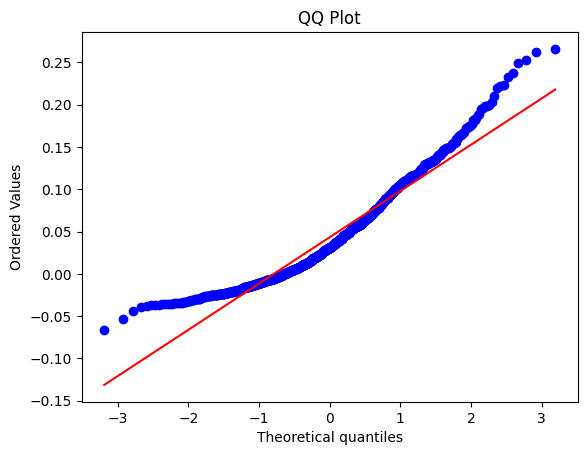

In [ ]:
from scipy import stats as scs
import matplotlib.pyplot as plt

scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')    # TODO: Погуглить что это Ку-Ку вообще такое
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, result)

0.0728782816709648